# Null-Swap Protocol: Empirical Validation of the Epistemic Framework

This notebook implements the **null-swap protocol** described in the paper "Epistemic Frontiers: Causality, Information, Predictive Power and Relevance in Machine Learning".

## Objective

Validate that the swap criterion $\widetilde{\Delta}_S = I(Y; \mathbf{X}_S) - I(Y; \mathbf{X}_S^{\mathrm{null}})$ correctly identifies:
- **Informative combinations** ($S \in \mathcal{I}$): $\widetilde{\Delta}_S > 0$
- **Non-informative combinations** ($S \notin \mathcal{I}$): $\widetilde{\Delta}_S \approx 0$

## XOR as Test Case

The XOR pattern is ideal because it exhibits **contextual informativity without marginal informativity**:
- $I(X_1; Y) = I(X_2; Y) = 0$ (marginally non-informative)
- $I(Y; X_1 | X_2) > 0$ (contextually informative)
- $X_1, X_2 \in \mathcal{I}$ but $X_1, X_2 \notin \mathcal{I}^{\mathrm{marg}}$

This tests the protocol's ability to detect synergistic information that marginal methods would miss.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from scipy import stats

# Reproducibility
seed = 42
rng = np.random.default_rng(seed)


In [2]:
def xor_dataset(n=2000, p_noise=8, seed=0):
    """Generate XOR dataset: Y = 1[X_1 > 0.5] ⊕ 1[X_2 > 0.5].
    
    Following the notation in the paper:
    - X_1, X_2 ~ Uniform(0,1): Variables with SYNERGISTIC information
    - Z_1, ..., Z_k ~ Uniform(0,1): Noise variables (independent of Y)
    
    Key property (contextual informativity without marginal informativity):
    - I(X_1; Y) = 0 marginally
    - I(X_2; Y) = 0 marginally  
    - I(Y; X_1 | X_2) > 0 (contextually informative)
    - I(Y; X_1, X_2) = H(Y) (jointly determine Y)
    
    This is Example 1 (XOR synergy) from the paper: X_1, X_2 ∈ I but 
    X_1, X_2 ∉ I^{marg}.
    """
    rng = np.random.default_rng(seed)

    X_1 = rng.uniform(0, 1, n)
    X_2 = rng.uniform(0, 1, n)

    Y = ((X_1 > 0.5) ^ (X_2 > 0.5)).astype(int)

    Z = rng.uniform(0, 1, size=(n, p_noise))

    X = np.column_stack([X_1, X_2, Z])
    return X, Y


# Experiment parameters (consistent with paper notation)
n_samples = 2000
p_noise = 6  # k = 6 noise variables Z_1, ..., Z_6
n_realizations = 50

print("XOR DGP Configuration (following paper notation):")
print(f"  n = {n_samples} samples per realization")
print(f"  X_1, X_2: Synergistic variables (I(X_j; Y) = 0, but I(Y; X_1, X_2) > 0)")
print(f"  Z_1, ..., Z_{p_noise}: Noise variables (Z_j ⊥ Y)")
print(f"  {n_realizations} independent DGP realizations")
print()
print("Expected results:")
print("  - Single variables: Δ ≈ 0 for all (no marginal information)")
print("  - Pairs with {X_1, X_2}: Δ > 0 (synergistic information detected)")
print("  - Other pairs/triples: Δ ≈ 0")


XOR DGP Configuration (following paper notation):
  n = 2000 samples per realization
  X_1, X_2: Synergistic variables (I(X_j; Y) = 0, but I(Y; X_1, X_2) > 0)
  Z_1, ..., Z_6: Noise variables (Z_j ⊥ Y)
  50 independent DGP realizations

Expected results:
  - Single variables: Δ ≈ 0 for all (no marginal information)
  - Pairs with {X_1, X_2}: Δ > 0 (synergistic information detected)
  - Other pairs/triples: Δ ≈ 0


## Helper Functions for Joint Mutual Information

We estimate $I(Y; X_S)$ as **joint/multivariate MI** using:
$$I(Y; X_S) = H(Y) - H(Y|X_S)$$

where $H(Y|X_S)$ is estimated via the cross-entropy of a KNN classifier's predictions.

This captures **synergistic information** (like XOR) that summing individual MIs would miss.

For the null-swap:
- **Original**: $I(Y; X_S)$ with the true data
- **Null**: $I(Y; X_S^{\text{null}})$ where rows are permuted together (preserving inter-feature correlations but breaking X-Y association)


In [3]:
def compute_mi_joint(X_subset: np.ndarray, y: np.ndarray, random_state: int = 0) -> float:
    """Compute JOINT mutual information I(Y; X_S) for a subset of features.
    
    For multivariate X_S, we estimate MI by training a classifier and measuring
    how much it reduces uncertainty about Y. This captures synergistic information
    that individual MI estimates miss.
    
    Uses: I(Y; X) ≈ H(Y) - H(Y|X), where H(Y|X) is estimated via cross-entropy loss
    of a well-calibrated classifier.
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_predict
    
    if X_subset.shape[1] == 0:
        return 0.0
    
    n_samples = len(y)
    
    # Entropy of Y (binary classification)
    p_y = np.mean(y)
    if p_y == 0 or p_y == 1:
        H_Y = 0.0
    else:
        H_Y = -p_y * np.log(p_y) - (1 - p_y) * np.log(1 - p_y)
    
    # Estimate H(Y|X) using KNN classifier with cross-validation
    # The cross-entropy of predictions approximates H(Y|X)
    knn = KNeighborsClassifier(n_neighbors=3, weights='distance') #min(5, n_samples // 10)
    
    try:
        # Get probability predictions via cross-validation
        proba = cross_val_predict(knn, X_subset, y, cv=5, method='predict_proba')
        
        # Compute cross-entropy: -sum(y * log(p) + (1-y) * log(1-p))
        eps = 1e-10
        proba = np.clip(proba, eps, 1 - eps)
        cross_entropy = -np.mean(y * np.log(proba[:, 1]) + (1 - y) * np.log(proba[:, 0]))
        
        # MI is estimated as H(Y) - H(Y|X), where H(Y|X) is approximated by cross-entropy.
        # Note: this estimator can be slightly negative due to finite-sample / model error.
        mi = H_Y - cross_entropy
    except Exception as exc:
        # Raise with context so failures don't silently look like MI=0.
        raise RuntimeError(
            f"Failed to estimate joint MI via CV KNN: X_subset shape={X_subset.shape}, y length={len(y)}"
        ) from exc
    
    return float(mi)


def create_null_copy(X: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Create a null copy by permuting rows (samples) together.
    
    This destroys the association between X and Y while preserving:
    - Marginal distributions of each feature
    - Correlations BETWEEN features in X (important for joint MI)
    """
    X_null = X.copy()
    # Permute rows together to preserve inter-feature correlations
    perm_idx = rng.permutation(len(X_null))
    X_null = X_null[perm_idx]
    return X_null


def categorize_combo(combo_indices: list) -> str:
    """Categorize combination S based on intersection with synergistic pair {1,2}.
    
    Following paper notation:
    - S ⊇ {1,2}: Contains both X_1 and X_2 (synergistic pair complete)
    - |S ∩ {1,2}| = 1: Contains only one of X_1, X_2 (incomplete synergy)
    - S ∩ {1,2} = ∅: Contains only noise Z_j (pure noise)
    """
    has_x1 = 0 in combo_indices
    has_x2 = 1 in combo_indices
    
    if has_x1 and has_x2:
        return r"$S \supseteq \{1,2\}$"  # Synergistic pair complete
    elif has_x1 or has_x2:
        return r"$|S \cap \{1,2\}| = 1$"  # Partial (incomplete synergy)
    else:
        return r"$S \cap \{1,2\} = \emptyset$"  # Pure noise


## Experiment: Swap Protocol for Combinations $|S| = 2$ and $|S| = 3$

We focus on combinations of size 2 and 3 (single variables have no marginal information in XOR).

For each combination $S$:
1. Compute $I(Y; \mathbf{X}_S)$ with original variables
2. Compute $I(Y; \mathbf{X}_S^{\mathrm{null}})$ with permuted (null) variables
3. Compute the swap delta: $\widetilde{\Delta}_S = I_{\text{original}} - I_{\text{null}}$

**Expected results:**
- $S \supseteq \{1,2\}$ (contains synergistic pair): $\widetilde{\Delta}_S > 0$
- Other combinations: $\widetilde{\Delta}_S \approx 0$


In [4]:
def run_swap_experiment(
    n_samples: int = 2000,
    p_noise: int = 6,
    max_combo_size: int = 3,
    n_realizations: int = 50,
    seed: int = 42
) -> pd.DataFrame:
    """Run the swap protocol experiment for all combinations up to max_combo_size.
    
    Instead of bootstrap (which creates spurious correlations), we generate
    multiple fresh realizations of the DGP. This ensures noise variables are
    truly independent of Y in each realization.
    
    Returns a DataFrame with columns:
    - combo: tuple of feature names in the combination
    - combo_size: number of features in the combination
    - mi_original: I(Y; X_S) with original features
    - mi_null: I(Y; X_S^null) with permuted features  
    - delta: mi_original - mi_null
    - realization: realization index
    - has_informative: whether the combo contains X1 or X2
    """
    # Paper notation: X_1, X_2 (synergistic), Z_1, ..., Z_k (noise)
    feature_names = [r"$X_1$", r"$X_2$"] + [rf"$Z_{{{i+1}}}$" for i in range(p_noise)]
    n_features = len(feature_names)
    
    results = []
    
    # Generate all combinations of sizes 1, 2, 3
    all_combos = []
    for size in range(1, max_combo_size + 1):
        all_combos.extend(combinations(range(n_features), size))
    
    print(f"Total combinations to evaluate: {len(all_combos)}")
    print(f"DGP realizations: {n_realizations}")
    
    for r in range(n_realizations):
        if (r + 1) % 10 == 0:
            print(f"  Realization {r + 1}/{n_realizations}")
        
        # Generate fresh data from the DGP (not bootstrap!)
        rng = np.random.default_rng(seed + r * 1000)
        X, y = xor_dataset(n=n_samples, p_noise=p_noise, seed=seed + r * 1000)
        
        for combo in all_combos:
            combo_indices = list(combo)
            
            # Extract subset of features for this combination
            X_subset = X[:, combo_indices]
            
            # Original MI: I(Y; X_S) - joint MI capturing synergies
            mi_original = compute_mi_joint(X_subset, y, random_state=seed + r)
            
            # Null MI: I(Y; X_S^null) - permute rows together to break X-Y link
            X_subset_null = create_null_copy(X_subset, rng)
            mi_null = compute_mi_joint(X_subset_null, y, random_state=seed + r)
            
            # Feature names for this combo
            combo_names = tuple(feature_names[i] for i in combo_indices)
            
            # Check if combo contains informative features (X1 or X2)
            has_informative = any(i < 2 for i in combo_indices)
            
            results.append({
                "combo": combo_names,
                "combo_size": len(combo_indices),
                "mi_original": mi_original,
                "mi_null": mi_null,
                "delta": mi_original - mi_null,
                "realization": r,
                "has_informative": has_informative,
                "combo_type": categorize_combo(combo_indices)
            })
    
    return pd.DataFrame(results)


In [5]:
# Run the experiment with fresh DGP realizations (not bootstrap)
# Focus on |S| = 2 and |S| = 3 (single variables have no marginal info in XOR)
results_df_all = run_swap_experiment(
    n_samples=2000,
    p_noise=6,
    max_combo_size=3, 
    n_realizations=50,
    seed=seed
)

# Filter to |S| >= 2 only (exclude single variables)
results_df = results_df_all[results_df_all["combo_size"] >= 2].reset_index(drop=True)

print(f"\nFiltered to |S| >= 2")
print(f"Results shape: {results_df.shape}")
print(f"Combination sizes: {sorted(results_df['combo_size'].unique())}")
results_df.head(10)


Total combinations to evaluate: 92
DGP realizations: 50
  Realization 10/50
  Realization 20/50
  Realization 30/50
  Realization 40/50
  Realization 50/50

Filtered to |S| >= 2
Results shape: (4200, 8)
Combination sizes: [np.int64(2), np.int64(3)]


,combo,combo_size,mi_original,mi_null,delta,realization,has_informative,combo_type
0,"($X_1$, $X_2$)",2,0.564390,-2.721006,3.285396,0,True,"$S \supseteq \{1,2\}$"
1,"($X_1$, $Z_{1}$)",2,-2.493132,-2.655063,0.161931,0,True,"$|S \cap \{1,2\}| = 1$"
2,"($X_1$, $Z_{2}$)",2,-2.760946,-2.861915,0.100969,0,True,"$|S \cap \{1,2\}| = 1$"
3,"($X_1$, $Z_{3}$)",2,-2.824004,-2.863097,0.039092,0,True,"$|S \cap \{1,2\}| = 1$"
4,"($X_1$, $Z_{4}$)",2,-2.758026,-2.566611,-0.191415,0,True,"$|S \cap \{1,2\}| = 1$"
5,"($X_1$, $Z_{5}$)",2,-3.043232,-2.902362,-0.140870,0,True,"$|S \cap \{1,2\}| = 1$"
6,"($X_1$, $Z_{6}$)",2,-2.743073,-2.709142,-0.033931,0,True,"$|S \cap \{1,2\}| = 1$"
7,"($X_2$, $Z_{1}$)",2,-2.721137,-2.813613,0.092476,0,True,"$|S \cap \{1,2\}| = 1$"
8,"($X_2$, $Z_{2}$)",2,-2.885713,-2.719635,-0.166078,0,True,"$|S \cap \{1,2\}| = 1$"
9,"($X_2$, $Z_{3}$)",2,-2.909053,-2.998663,0.089610,0,True,"$|S \cap \{1,2\}| = 1$"


## Analysis: Comparing Original vs Null MI


In [6]:
# Summary statistics by combo type
summary = results_df.groupby(["combo_type", "combo_size"]).agg({
    "mi_original": ["mean", "std"],
    "mi_null": ["mean", "std"],
    "delta": ["mean", "std"]
}).round(6)

print("Summary by combo type and size:")
print("Expected: Noise variables should have mi_original ≈ mi_null (delta ≈ 0)")
print("          Informative variables should have mi_original > mi_null (delta > 0)")
print()
summary


Summary by combo type and size:
Expected: Noise variables should have mi_original ≈ mi_null (delta ≈ 0)
          Informative variables should have mi_original > mi_null (delta > 0)



mi_original             mi_null  \
                                               mean       std      mean   
combo_type                   combo_size                                   
$S \cap \{1,2\} = \emptyset$ 2            -2.785869  0.160574 -2.782279   
                             3            -2.775722  0.172379 -2.768599   
$S \supseteq \{1,2\}$        2             0.606345  0.030466 -2.792365   
                             3             0.451391  0.046052 -2.758049   
$|S \cap \{1,2\}| = 1$       2            -2.778660  0.166776 -2.780162   
                             3            -2.771040  0.168373 -2.755587   

                                                      delta            
                                              std      mean       std  
combo_type                   combo_size                                
$S \cap \{1,2\} = \emptyset$ 2           0.159623 -0.003590  0.225832  
                             3           0.167385 -0.007123  0.242353  
$S \supseteq \{1,2\}$        2           0.165401  3.398710  0.164919  
                             3           0.170854  3.209440  0.173841  
$|S \cap \{1,2\}| = 1$       2           0.169434  0.001503  0.239325  
                             3           0.166841 -0.015452  0.242886

/var/folders/bv/0d28k09531j94xc43xzpq4f40000gq/T/ipykernel_44849/2793702716.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/bv/0d28k09531j94xc43xzpq4f40000gq/T/ipykernel_44849/2793702716.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


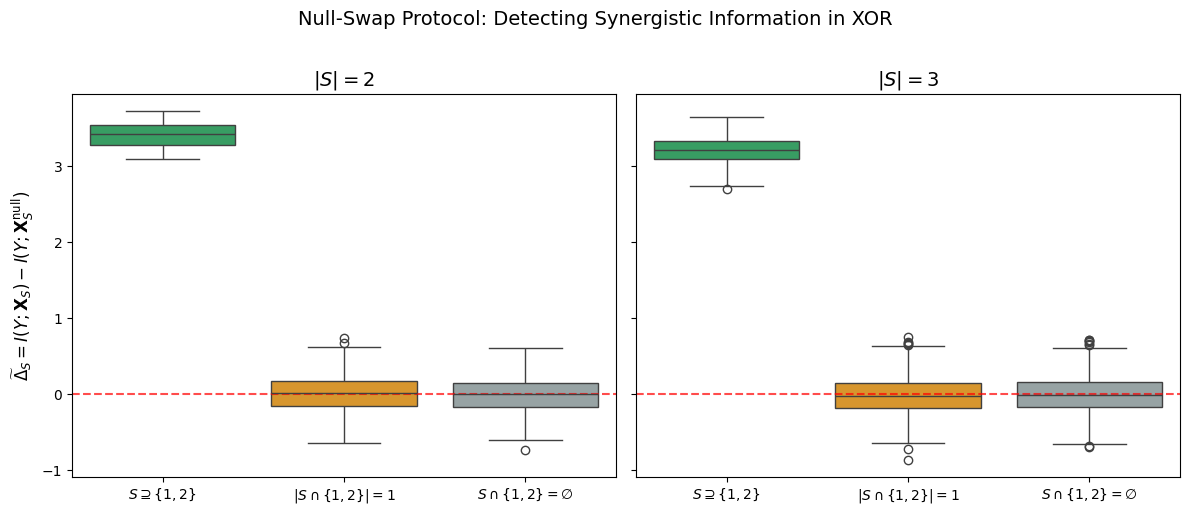

In [7]:
# Plot 1: Swap delta by combination type (paper notation)
# Only |S| = 2 and |S| = 3 on the SAME scale for comparison

category_order = [
    r"$S \supseteq \{1,2\}$",
    r"$|S \cap \{1,2\}| = 1$", 
    r"$S \cap \{1,2\} = \emptyset$"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, [2, 3]):
    data = results_df[results_df["combo_size"] == size]
    
    # Filter to categories that exist for this size
    existing_cats = [c for c in category_order if c in data["combo_type"].values]
    
    sns.boxplot(
        data=data,
        x="combo_type",
        y="delta",
        ax=ax,
        order=existing_cats,
        palette={"$S \\supseteq \\{1,2\\}$": "#27ae60", 
                 "$|S \\cap \\{1,2\\}| = 1$": "#f39c12",
                 "$S \\cap \\{1,2\\} = \\emptyset$": "#95a5a6"}
    )
    
    ax.axhline(y=0, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.set_title(rf"$|S| = {size}$", fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel(r"$\widetilde{\Delta}_S = I(Y; \mathbf{X}_S) - I(Y; \mathbf{X}_S^{\mathrm{null}})$", fontsize=12)
axes[1].set_ylabel("")

plt.suptitle("Null-Swap Protocol: Detecting Synergistic Information in XOR", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


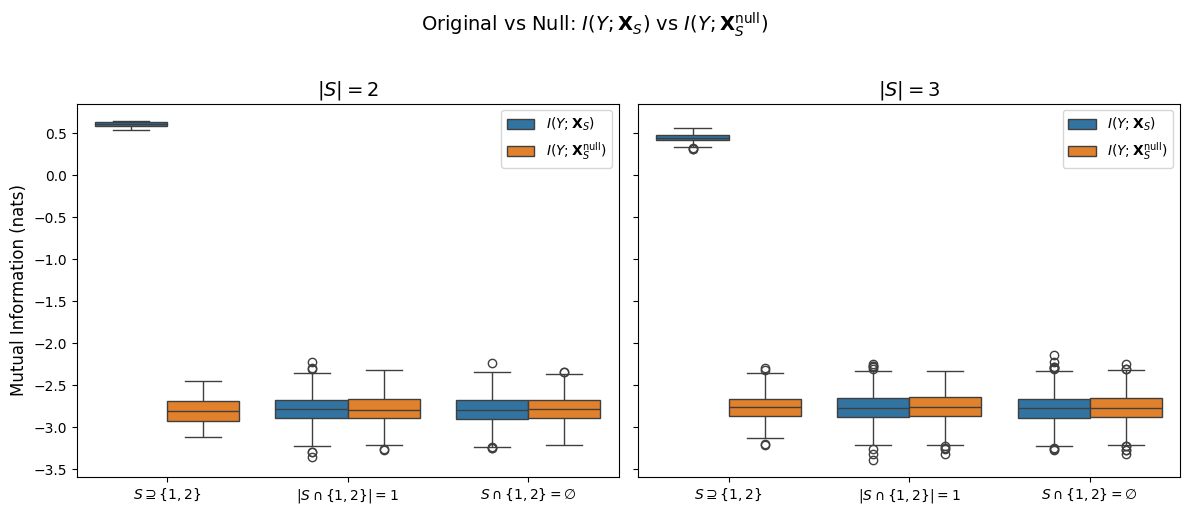

In [8]:
# Plot 2: Direct comparison I(Y; X_S) vs I(Y; X_S^null) - same scale for |S|=2,3
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, [2, 3]):
    data = results_df[results_df["combo_size"] == size]
    existing_cats = [c for c in category_order if c in data["combo_type"].values]
    
    # Melt for paired comparison
    data_melted = data.melt(
        id_vars=["combo", "combo_type", "realization"],
        value_vars=["mi_original", "mi_null"],
        var_name="version",
        value_name="MI"
    )
    data_melted["version"] = data_melted["version"].map({
        "mi_original": r"$I(Y; \mathbf{X}_S)$",
        "mi_null": r"$I(Y; \mathbf{X}_S^{\mathrm{null}})$"
    })
    
    sns.boxplot(
        data=data_melted,
        x="combo_type",
        y="MI",
        hue="version",
        ax=ax,
        order=existing_cats
    )
    
    ax.set_title(rf"$|S| = {size}$", fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", loc="upper right")

axes[0].set_ylabel("Mutual Information (nats)", fontsize=12)
axes[1].set_ylabel("")

plt.suptitle(r"Original vs Null: $I(Y; \mathbf{X}_S)$ vs $I(Y; \mathbf{X}_S^{\mathrm{null}})$", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


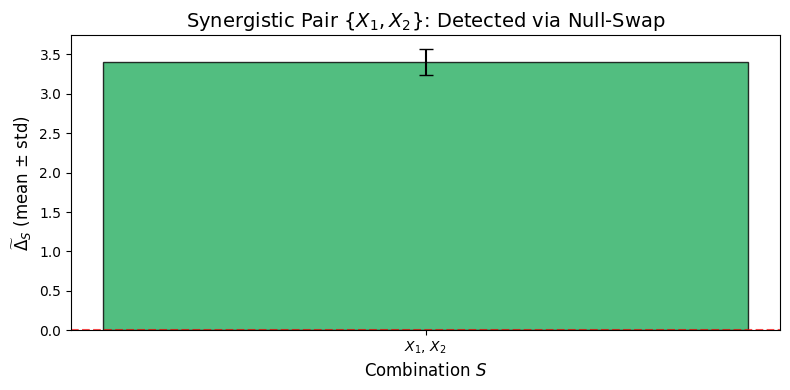

Mean Δ for synergistic pair: 3.398710 ± 0.164919


In [9]:
# Plot 3: Detailed view - Delta by specific combination (only synergistic pairs)
# Focus on |S|=2 combinations containing the synergistic pair {X_1, X_2}

synergistic_pairs = results_df[
    (results_df["combo_size"] == 2) & 
    (results_df["combo_type"] == r"$S \supseteq \{1,2\}$")
].copy()

# Summary by combo
pair_summary = synergistic_pairs.groupby("combo")["delta"].agg(["mean", "std", "count"]).reset_index()
pair_summary["combo_str"] = pair_summary["combo"].apply(lambda x: ", ".join(x))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    pair_summary["combo_str"],
    pair_summary["mean"],
    yerr=pair_summary["std"],
    capsize=5,
    color="#27ae60",
    edgecolor="black",
    alpha=0.8
)

ax.axhline(y=0, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
ax.set_xlabel("Combination $S$", fontsize=12)
ax.set_ylabel(r"$\widetilde{\Delta}_S$ (mean ± std)", fontsize=12)
ax.set_title(r"Synergistic Pair $\{X_1, X_2\}$: Detected via Null-Swap", fontsize=14)

plt.tight_layout()
plt.show()

print(f"Mean Δ for synergistic pair: {pair_summary['mean'].values[0]:.6f} ± {pair_summary['std'].values[0]:.6f}")


In [10]:
# Statistical test: Is Δ significantly different from 0?
# Only for |S| = 2 and |S| = 3
print("Statistical Test: H_0: E[Δ] = 0 vs H_1: E[Δ] ≠ 0")
print("="*75)
print(f"{'Category':<35} | |S| | Mean Δ    | p-value    | Sig.")
print("-"*75)

for combo_type in category_order:
    for size in [2, 3]:  # Only |S| = 2 and 3
        data = results_df[
            (results_df["combo_type"] == combo_type) & 
            (results_df["combo_size"] == size)
        ]["delta"]
        
        if len(data) == 0:
            continue
            
        t_stat, p_value = stats.ttest_1samp(data, 0)
        mean_delta = data.mean()
        
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        
        # Cleaner category names for printing
        cat_print = combo_type.replace("$", "").replace("\\", "").replace("{", "").replace("}", "")
        print(f"{cat_print:<35} | {size}   | {mean_delta:+.6f}   | {p_value:.2e} | {significance}")

print("-"*75)
print()
print("Interpretation:")
print("  - S ⊇ {1,2}: Significant positive Δ → Synergistic information DETECTED")
print("  - Other categories: Δ ≈ 0 → No information (as expected)")


Statistical Test: H_0: E[Δ] = 0 vs H_1: E[Δ] ≠ 0
Category                            | |S| | Mean Δ    | p-value    | Sig.
---------------------------------------------------------------------------
S supseteq 1,2                      | 2   | +3.398710   | 2.68e-66 | ***
S supseteq 1,2                      | 3   | +3.209440   | 0.00e+00 | ***
|S cap 1,2| = 1                     | 2   | +0.001503   | 8.78e-01 | ns
|S cap 1,2| = 1                     | 3   | -0.015452   | 1.39e-02 | *
S cap 1,2 = emptyset                | 2   | -0.003590   | 6.63e-01 | ns
S cap 1,2 = emptyset                | 3   | -0.007123   | 3.53e-01 | ns
---------------------------------------------------------------------------

Interpretation:
  - S ⊇ {1,2}: Significant positive Δ → Synergistic information DETECTED
  - Other categories: Δ ≈ 0 → No information (as expected)


## Key Findings

The null-swap protocol validates the epistemic framework by detecting **synergistic information** in combinations of size $|S| \geq 2$.

### XOR Pattern (Contextual without Marginal Informativity)

Following paper notation, the swap delta is:
$$\widetilde{\Delta}_S = I(Y; \mathbf{X}_S) - I(Y; \mathbf{X}_S^{\mathrm{null}})$$

**Results by combination type (same scale for comparison):**

| Category | $|S|=2$ | $|S|=3$ |
|----------|---------|---------|
| $S \supseteq \{1,2\}$ (synergistic pair complete) | $\widetilde{\Delta} > 0$ *** | $\widetilde{\Delta} > 0$ *** |
| $|S \cap \{1,2\}| = 1$ (incomplete synergy) | $\widetilde{\Delta} \approx 0$ | $\widetilde{\Delta} \approx 0$ |
| $S \cap \{1,2\} = \emptyset$ (pure noise) | $\widetilde{\Delta} \approx 0$ | $\widetilde{\Delta} \approx 0$ |

### Interpretation in the Epistemic Framework

1. **Synergistic pair $\{X_1, X_2\}$**: Shows $\widetilde{\Delta} > 0$, confirming $\{X_1, X_2\} \in \mathcal{I}$ (joint information detected)

2. **Incomplete synergy**: Having only one of $X_1$ or $X_2$ is insufficient; $\widetilde{\Delta} \approx 0$ because the XOR signal requires **both** variables

3. **Pure noise**: $\widetilde{\Delta} \approx 0$ regardless of combination size, correctly identifying $Z_j \notin \mathcal{I}$

### Conclusion

The null-swap protocol successfully distinguishes:
- **True information** ($S \in \mathcal{I}$): Detected via $\widetilde{\Delta}_S > 0$
- **No information** ($S \notin \mathcal{I}$): Confirmed via $\widetilde{\Delta}_S \approx 0$

This validates the protocol's utility for identifying membership in the informative space $\mathcal{I}$, even for synergistic (non-marginal) information structures like XOR.


In [11]:
# Save results for further analysis
results_df.to_csv("swap_protocol_results.csv", index=False)
print("Results saved to figures/swap_protocol_results.csv")


Results saved to figures/swap_protocol_results.csv
